<a href="https://colab.research.google.com/github/JGradone/Topics-Sentinel/blob/main/Redwing_Real_Time.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Topics in Marine Science: Redwing Real Time Data
*Written by Joe Gradone, Rutgers University, October 21, 2025*

## Getting Started

Jupyter notebooks have two kids of cells.  "Markdown" cells, like this one which can contain formatted text, and "Code" cells, which contain the code you will run.

To execute the code in a cell, you can either:
* click the **Play** icon on the left
* type **Cmd (or Ctrl) + Enter** to run the cell in place
* or type **Shift + Enter** to run the cell and move the focus to the next cell.

You can try all these options on our first very elaborate piece of code in the next cell.

After you execute the cell, the result will automatically display underneath the cell.

In [1]:
pip install erddapy

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from erddapy import ERDDAP


### This is a function to help with loading in glider data
def get_erddap_dataset(ds_id, server = 'https://slocum-data.marine.rutgers.edu/erddap/', variables=None, constraints=None, filetype='dataframe'):
    ## Written by Mike Smith
    """
    Returns a netcdf dataset for a specified dataset ID (or dataframe if dataset cannot be converted to xarray)
    :param ds_id: dataset ID e.g. ng314-20200806T2040
    :param variables: optional list of variables
    :param constraints: optional list of constraints
    :param filetype: optional filetype to return, 'nc' (default) or 'dataframe'
    :return: netcdf dataset
    """
    variables = variables or None
    constraints = constraints or None
    filetype = filetype or 'nc'

    e = ERDDAP(server,
               protocol='tabledap',
               response='nc')
    e.dataset_id = ds_id
    if constraints:
        e.constraints = constraints
    if variables:
        e.variables = variables
    if filetype == 'nc':
        try:
            ds = e.to_xarray()
            ds = ds.sortby(ds.time)
        except OSError:
            print('No dataset available for specified constraints: {}'.format(ds_id))
            ds = []
        except TypeError:
            print('Cannot convert to xarray, providing dataframe: {}'.format(ds_id))
            ds = e.to_pandas().dropna()
    elif filetype == 'dataframe':
        #ds = e.to_pandas().dropna()
        ds = e.to_pandas().dropna(how='all')
    else:
        print('Unrecognized filetype: {}. Needs to  be "nc" or "dataframe"'.format(filetype))

    return ds



## Load data

We will load the glider data from this server: https://slocum-data.marine.rutgers.edu/erddap/

Here is the list of all of the specific variables for Redwing: https://slocum-data.marine.rutgers.edu/erddap/tabledap/redwing-20251011T1511-trajectory-raw-rt.html


In [7]:
## The specific ID for redwing
ds_id = 'redwing-20251011T1511-trajectory-raw-rt'
## Load flight data
variables = ['time', 'm_battery_amp_hours_remaining'] # m_vmg_to_wpt = velocity "made good" to waypoint [m/s]
## Load the data
redwing = get_erddap_dataset(ds_id, variables = variables)
## Change the name of the columns
redwing.columns = variables
## Change the format of time variable
redwing['time'] = pd.to_datetime(redwing['time'], format='%Y-%m-%dT%H:%M:%SZ')
## Drop na
redwing = redwing.dropna().reset_index(drop=True)
## Print out the dataframe
redwing

,time,m_battery_amp_hours_remaining
0,2025-10-11 15:11:27,833.910
1,2025-10-11 15:26:16,833.801
2,2025-10-11 15:41:16,833.699
3,2025-10-11 18:08:50,832.727
4,2025-10-11 18:13:11,832.719
...,...,...
1821,2025-10-27 10:02:54,737.277
1822,2025-10-27 10:17:54,737.266
1823,2025-10-27 10:32:54,737.258
1824,2025-10-27 10:47:55,737.242


## Make some plots!

Text(0.5, 0, 'Time')

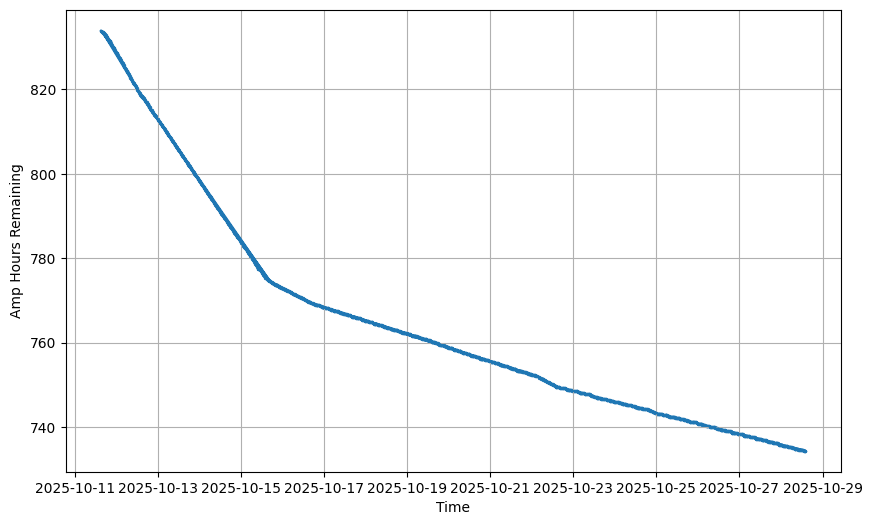

In [9]:
plt.figure(figsize=(10,6))
plt.scatter(redwing.time, redwing.m_battery_amp_hours_remaining,s=2)
plt.grid()
plt.ylabel('Amp Hours Remaining')
plt.xlabel('Time')

## Calculate amphr per day rate

/tmp/ipython-input-2229808681.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


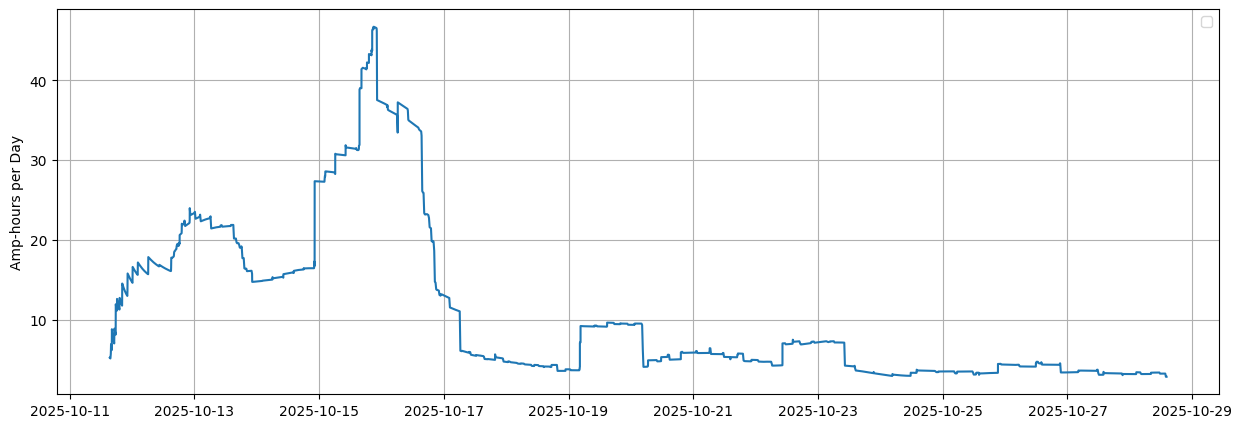

In [87]:
redwing.index = pd.to_datetime(redwing.time)
redwing = redwing.sort_index()

# Rolling and differencing
redwing['amp_hour_diff'] = (
    np.abs(redwing['m_battery_amp_hours_remaining'].rolling('2h').mean().diff())
    .rolling('24h').mean()
)

redwing['time_diff'] = redwing.index.to_series().diff().dt.total_seconds()
redwing['amp_hour_per_day'] = redwing['amp_hour_diff'] / redwing['time_diff'] * 86400

# Median filter + rolling mean
redwing['amp_hour_per_day_smooth'] = redwing['amp_hour_per_day'].rolling('24h').mean()

# Plot
plt.figure(figsize=(15,5))
plt.plot(redwing.index, redwing['amp_hour_per_day_smooth'])
plt.ylabel('Amp-hours per Day')
plt.legend()
plt.grid()
